In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
train_dir = '/content/drive/MyDrive/tomato /train '
val_dir = '/content/drive/MyDrive/tomato /val '

In [3]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 10000 images belonging to 10 classes.
Found 1001 images belonging to 10 classes.


In [4]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3221s 10s/step - accuracy: 0.6100 - loss: 1.1230 - val_accuracy: 0.7532 - val_loss: 0.7461
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.7559 - loss: 0.7185 - val_accuracy: 0.8032 - val_loss: 0.5679
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - accuracy: 0.7860 - loss: 0.6172 - val_accuracy: 0.8132 - val_loss: 0.5472
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 589s 2s/step - accuracy: 0.8090 - loss: 0.5585 - val_accuracy: 0.8192 - val_loss: 0.5472
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.8200 - loss: 0.5353 - val_accuracy: 0.8392 - val_loss: 0.5049
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 624s 2s/step - accuracy: 0.8296 - loss: 0.4930 - val_accuracy: 0.8362 - val_loss: 0.4861
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.8381 - loss: 0.4809 - val_accuracy: 0.8342 - val_loss: 0.4953
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 574s 2s/step - accuracy: 0.8359 - loss: 0.4758 - val_ac

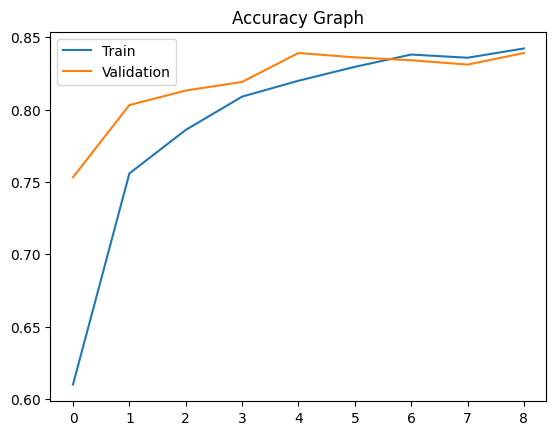

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy Graph')
plt.show()

In [11]:
from sklearn.metrics import classification_report

pred = model.predict(val_gen)
y_pred = pred.argmax(axis=1)

print(classification_report(val_gen.classes, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step
              precision    recall  f1-score   support

           0       0.09      0.09      0.09       100
           1       0.09      0.07      0.08       100
           2       0.09      0.11      0.10       100
           3       0.05      0.06      0.06       100
           4       0.13      0.11      0.12       100
           5       0.12      0.08      0.10       100
           6       0.14      0.18      0.16       100
           7       0.12      0.12      0.12       100
           8       0.09      0.09      0.09       101
           9       0.06      0.06      0.06       100

    accuracy                           0.10      1001
   macro avg       0.10      0.10      0.10      1001
weighted avg       0.10      0.10      0.10      1001



In [12]:
model.save("tomato_model.keras")